# AncestryClassifier — Colab Training

Run preprocessing locally with Snakemake first:
```bash
snakemake --cores 4 prepare_training_data simulate_admixed
```
Upload `data/dataset.h5` and `data/admixed_test.h5` to Google Drive, then set `DRIVE_DIR` below.


In [7]:
# ── Cell 1: config — re-run this first after every runtime restart ─────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR     = '/content/drive/MyDrive/gene461'          # <-- change if needed
REPO          = '/content/gene_461_final_project'
WINDOW_SIZE   = 1000

DATA_H5       = f'{DRIVE_DIR}/dataset.h5'
ADMIXED_H5    = f'{DRIVE_DIR}/admixed_test.h5'
CKPT_OUT      = f'{DRIVE_DIR}/checkpoints/best_model.pt'
CONFUSION_OUT = f'{DRIVE_DIR}/confusion_matrix.png'
KARYOGRAM_OUT = f'{DRIVE_DIR}/lai_karyogram.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ── Cell 2: one-time setup (clone repo + install deps) ────────────────────
import subprocess, os

if not os.path.exists(REPO):
    subprocess.run(
        ['git', 'clone', 'https://github.com/aszatrowski/gene_461_final_project', REPO],
        check=True
    )
else:
    subprocess.run(['git', '-C', REPO, 'pull'], check=True)

%pip install -q torch h5py numpy pandas scikit-learn matplotlib wandb

In [9]:
# ── Cell 3: verify GPU ─────────────────────────────────────────────────────
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CUDA available: True
GPU: Tesla T4


In [10]:
# ── Cell 5: W&B login (one-time per session) ───────────────────────────────
import wandb
wandb.login()

True

In [12]:
# ── Cell 6: sweep config ───────────────────────────────────────────────────
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_acc', 'goal': 'maximize'},
    'parameters': {
        'window_size': {'values': [2500, 5000, 10000, 20000]},
        'lr':          {'distribution': 'log_uniform_values', 'min': 1e-4, 'max': 1e-2},
        'conv_arch':   {'values': [
            # undilated baselines
            '32,64_7,5',
            '64,128_7,5',
            '32,64,128_7,5,3',
            # dilated — ERF ~1,600 SNPs (covers 2.5k window partially)
            '32,64,128_7,7,7_1,4,16',
            '64,128,256_7,7,7_1,4,16',
            # dilated — ERF ~3,270 SNPs (covers 2.5k window)
            '32,64,128_7,7,7_1,8,32',
            '64,128,256_7,7,7_1,8,32',
            # dilated — ERF ~6,250–6,550 SNPs (covers 5k window)
            '32,64,128_7,7,7_1,8,64',
            '64,128,256_7,7,7_1,8,64',
            '32,64,128_7,7,7_1,4,64',   # skip-ratio variant
            '32,64,128_7,7,7_4,16,64',
            # dilated — ERF ~12,680 SNPs (covers 10k window)
            '32,64,128_7,7,7_1,16,128',
            '64,128,256_7,7,7_1,16,128',
            # dilated — ERF ~25,350 SNPs (covers 20k window)
            '32,64,128_7,7,7_1,32,256',
            '64,128,256_7,7,7_1,32,256',
        ]},
        'global_pool': {'values': [False]},
        'dropout':     {'distribution': 'uniform', 'min': 0.1, 'max': 0.5},
    },
}

sweep_id = wandb.sweep(sweep_config, project='ancestry_cnn')
print('Sweep ID:', sweep_id)

Create sweep with ID: zzj54cl5
Sweep URL: https://wandb.ai/aszatrowski-university-of-chicago/ancestry_cnn/sweeps/zzj54cl5
Sweep ID: zzj54cl5


In [ ]:
# ── Cell 7: run sweep agent (needs Cells 1, 3, 5, 6) ──────────────────────
import sys, importlib.util

def _load_module(name, path):
    """Load a .py file from an explicit path, registering it in sys.modules
    so that internal cross-imports (e.g. train.py → model.py) resolve correctly."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_load_module('model', f'{REPO}/scripts/model.py')
_train = _load_module('train', f'{REPO}/scripts/train.py')
run_training    = _train.run_training
parse_conv_arch = _train.parse_conv_arch

SWEEP_EPOCHS = 10
SWEEP_COUNT  = 20

def sweep_fn():
    with wandb.init() as run:
        w = dict(run.config)
        channels, kernels, dilations = parse_conv_arch(w['conv_arch'])
        cfg = {
            'window_size':    w['window_size'],
            'lr':             w['lr'],
            'conv_channels':  channels,
            'kernel_sizes':   kernels,
            'dilation_rates': dilations,
            'global_pool':    w['global_pool'],
            'dropout':        w['dropout'],
            'epochs':         SWEEP_EPOCHS,
            'batch_size':     512,
            'num_workers':    2,
            'use_wandb':      True,
        }
        run_training(cfg, DATA_H5, None, device)

wandb.agent(sweep_id, sweep_fn, count=SWEEP_COUNT)

wandb: Agent Starting Run: 4lwl7kk8 with config:
wandb: 	conv_arch: 32,64,128_7,7,7_4,16,64
wandb: 	dropout: 0.2974054089356808
wandb: 	global_pool: False
wandb: 	lr: 0.002892460821039577
wandb: 	window_size: 20000
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  train windows: 14,016  |  val windows: 3,008
  params: 10,297,733
Epoch   1/10  loss=20.1360  train_acc=0.2707  val_acc=0.1616
Epoch   2/10  loss=1.4043  train_acc=0.3231  val_acc=0.4209
Epoch   3/10  loss=1.2938  train_acc=0.3801  val_acc=0.4814
Epoch   4/10  loss=1.2422  train_acc=0.4150  val_acc=0.5745
Epoch   5/10  loss=1.2010  train_acc=0.4371  val_acc=0.5871
Epoch   6/10  loss=1.1777  train_acc=0.4559  val_acc=0.5967
Epoch   7/10  loss=1.1476  train_acc=0.4700  val_acc=0.6124
Epoch   8/10  loss=1.1464  train_acc=0.4769  val_acc=0.6217
Epoch   9/10  loss=1.1250  train_acc=0.4833  val_acc=0.6170
Epoch  10/10  loss=1.1362  train_acc=0.4785  val_acc=0.6170

Best val accuracy: 0.6217


epoch,▁▂▃▃▄▅▆▆▇█
loss,█▁▁▁▁▁▁▁▁▁
train_acc,▁▃▅▆▆▇████
val_acc,▁▅▆▇▇█████
best_val_acc,0.62168
epoch,10
loss,1.13622
train_acc,0.47845
val_acc,0.61702


wandb: Agent Starting Run: a06oz7h2 with config:
wandb: 	conv_arch: 64,128_7,5
wandb: 	dropout: 0.10721952347177312
wandb: 	global_pool: False
wandb: 	lr: 0.00505200022772558
wandb: 	window_size: 10000
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  train windows: 29,784  |  val windows: 6,392
  params: 20,523,525
Epoch   1/10  loss=29.8217  train_acc=0.2026  val_acc=0.2630
Epoch   2/10  loss=1.4909  train_acc=0.2877  val_acc=0.4027
Epoch   3/10  loss=1.3810  train_acc=0.3462  val_acc=0.4155
Epoch   4/10  loss=1.3376  train_acc=0.3595  val_acc=0.4377
Epoch   5/10  loss=1.3129  train_acc=0.3712  val_acc=0.4479
Epoch   6/10  loss=1.3010  train_acc=0.3729  val_acc=0.4371
Epoch   7/10  loss=1.2884  train_acc=0.3717  val_acc=0.4471
Epoch   8/10  loss=1.2754  train_acc=0.3807  val_acc=0.4498
Epoch   9/10  loss=1.2712  train_acc=0.3800  val_acc=0.4521
Epoch  10/10  loss=1.2723  train_acc=0.3785  val_acc=0.4507

Best val accuracy: 0.4521


...

wandb: Agent Starting Run: 9razvpf9 with config:
wandb: 	conv_arch: 64,128,256_7,7,7_1,32,256
wandb: 	dropout: 0.15484091181094928
wandb: 	global_pool: False
wandb: 	lr: 0.00012300863220666817
wandb: 	window_size: 20000
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  train windows: 14,016  |  val windows: 3,008
  params: 20,737,285
Epoch   1/10  loss=2.5880  train_acc=0.3092  val_acc=0.2207
Epoch   2/10  loss=1.1788  train_acc=0.5006  val_acc=0.4023
Epoch   3/10  loss=1.0037  train_acc=0.6018  val_acc=0.6360
Epoch   4/10  loss=0.8697  train_acc=0.6771  val_acc=0.7207
Epoch   5/10  loss=0.7771  train_acc=0.7265  val_acc=0.7503
Epoch   6/10  loss=0.7105  train_acc=0.7497  val_acc=0.7896
Epoch   7/10  loss=0.6590  train_acc=0.7788  val_acc=0.7909
Epoch   8/10  loss=0.6347  train_acc=0.7916  val_acc=0.7969
Epoch   9/10  loss=0.6252  train_acc=0.7957  val_acc=0.8108
Epoch  10/10  loss=0.6138  train_acc=0.8037  val_acc=0.8105

Best val accuracy: 0.8108


epoch,▁▂▃▃▄▅▆▆▇█
loss,█▃▂▂▂▁▁▁▁▁
train_acc,▁▄▅▆▇▇████
val_acc,▁▃▆▇▇█████
best_val_acc,0.81084
epoch,10
loss,0.61379
train_acc,0.80372
val_acc,0.81051


wandb: Agent Starting Run: f9wn2qne with config:
wandb: 	conv_arch: 64,128,256_7,7,7_1,32,256
wandb: 	dropout: 0.1616351474291968
wandb: 	global_pool: False
wandb: 	lr: 0.00012668690167244825
wandb: 	window_size: 20000
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  train windows: 14,016  |  val windows: 3,008
  params: 20,737,285
Epoch   1/10  loss=2.6868  train_acc=0.2875  val_acc=0.3225
Epoch   2/10  loss=1.2519  train_acc=0.4761  val_acc=0.5419
Epoch   3/10  loss=1.1076  train_acc=0.5586  val_acc=0.5406
Epoch   4/10  loss=0.9931  train_acc=0.6265  val_acc=0.6825
Epoch   5/10  loss=0.8936  train_acc=0.6697  val_acc=0.7473
Epoch   6/10  loss=0.8467  train_acc=0.6928  val_acc=0.7842
Epoch   7/10  loss=0.7838  train_acc=0.7200  val_acc=0.7889
Epoch   8/10  loss=0.7437  train_acc=0.7394  val_acc=0.8022


In [6]:
# ── Cell 8: retrain Run A (best accuracy, undilated) + Run B (best dilated) ────
# Needs Cells 1, 3, 5, 7
import os
import sys, importlib.util

def _load_module(name, path):
    """Load a .py file from an explicit path, registering it in sys.modules
    so that internal cross-imports (e.g. train.py → model.py) resolve correctly."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_load_module('model', f'{REPO}/scripts/model.py')
_train = _load_module('train', f'{REPO}/scripts/train.py')
run_training    = _train.run_training
parse_conv_arch = _train.parse_conv_arch
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)

CKPT_OUT_A = f'{DRIVE_DIR}/checkpoints/model_a_undilated_20k.pt'
CKPT_OUT_B = f'{DRIVE_DIR}/checkpoints/model_b_dilated_20k.pt'

# Run A: best undilated — 32,64,128_7,5,3 @ window=20k (highest sweep val_acc=0.832)
cfg_a = {
    'window_size':    20000,
    'lr':             1.53e-4,
    'conv_channels':  [32, 64, 128],
    'kernel_sizes':   [7, 5, 3],
    'dilation_rates': [1, 1, 1],
    'global_pool':    False,
    'dropout':        0.340,
    'epochs':         25,
    'batch_size':     512,
    'num_workers':    2,
    'use_wandb':      True,
}
with wandb.init(project='ancestry_cnn', config=cfg_a, name='run_a_undilated_20k'):
    run_training(cfg_a, DATA_H5, CKPT_OUT_A, device)

# Run B: best dilated — 64,128,256_7,7,7_1,8,32 @ window=20k
cfg_b = {
    'window_size':    20000,
    'lr':             2.96e-4,
    'conv_channels':  [64, 128, 256],
    'kernel_sizes':   [7, 7, 7],
    'dilation_rates': [1, 8, 32],
    'global_pool':    False,
    'dropout':        0.103,
    'epochs':         25,
    'batch_size':     512,
    'num_workers':    2,
    'use_wandb':      True,
}
with wandb.init(project='ancestry_cnn', config=cfg_b, name='run_b_dilated_20k'):
    run_training(cfg_b, DATA_H5, CKPT_OUT_B, device)

  train windows: 14,016  |  val windows: 3,008
  params: 10,260,869
Epoch   1/25  loss=2.2163  train_acc=0.3129  val_acc=0.2118
  -> saved checkpoint (val_acc=0.2118)
Epoch   2/25  loss=1.2103  train_acc=0.4933  val_acc=0.5336
  -> saved checkpoint (val_acc=0.5336)
Epoch   3/25  loss=1.0602  train_acc=0.5666  val_acc=0.6785
  -> saved checkpoint (val_acc=0.6785)
Epoch   4/25  loss=0.9605  train_acc=0.6082  val_acc=0.7237
  -> saved checkpoint (val_acc=0.7237)
Epoch   5/25  loss=0.8911  train_acc=0.6406  val_acc=0.7453
  -> saved checkpoint (val_acc=0.7453)
Epoch   6/25  loss=0.8265  train_acc=0.6702  val_acc=0.7763
  -> saved checkpoint (val_acc=0.7763)
Epoch   7/25  loss=0.7853  train_acc=0.6953  val_acc=0.8035
  -> saved checkpoint (val_acc=0.8035)
Epoch   8/25  loss=0.7431  train_acc=0.7176  val_acc=0.8218
  -> saved checkpoint (val_acc=0.8218)
Epoch   9/25  loss=0.6909  train_acc=0.7428  val_acc=0.8271
  -> saved checkpoint (val_acc=0.8271)
Epoch  10/25  loss=0.6695  train_acc=0.75

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
loss,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▆▆▆▇▇▇▇▇▇███████████
val_acc,▁▄▆▆▇▇▇▇█████████████████
best_val_acc,0.87134
epoch,25
loss,0.49607
train_acc,0.82449
val_acc,0.86968


  train windows: 14,016  |  val windows: 3,008
  params: 20,737,285
Epoch   1/25  loss=6.3745  train_acc=0.3030  val_acc=0.1998
  -> saved checkpoint (val_acc=0.1998)
Epoch   2/25  loss=1.1279  train_acc=0.5473  val_acc=0.5991
  -> saved checkpoint (val_acc=0.5991)
Epoch   3/25  loss=0.9096  train_acc=0.6459  val_acc=0.6749
  -> saved checkpoint (val_acc=0.6749)
Epoch   4/25  loss=0.7982  train_acc=0.6929  val_acc=0.7364
  -> saved checkpoint (val_acc=0.7364)
Epoch   5/25  loss=0.7171  train_acc=0.7294  val_acc=0.7606
  -> saved checkpoint (val_acc=0.7606)
Epoch   6/25  loss=0.6710  train_acc=0.7486  val_acc=0.7693
  -> saved checkpoint (val_acc=0.7693)
Epoch   7/25  loss=0.6252  train_acc=0.7658  val_acc=0.7789
  -> saved checkpoint (val_acc=0.7789)
Epoch   8/25  loss=0.5892  train_acc=0.7818  val_acc=0.7949
  -> saved checkpoint (val_acc=0.7949)
Epoch   9/25  loss=0.5422  train_acc=0.8013  val_acc=0.8005
  -> saved checkpoint (val_acc=0.8005)
Epoch  10/25  loss=0.5179  train_acc=0.81

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▅▆▆▆▇▇▇▇▇▇▇████████████
val_acc,▁▅▆▇▇▇▇▇█████████████████
best_val_acc,0.84209
epoch,25
loss,0.35161
train_acc,0.88078
val_acc,0.83644


In [11]:
# ── Cell 9: evaluate both checkpoints (needs Cell 1 only) ─────────────────
import os
os.makedirs(f'{DRIVE_DIR}/outputs', exist_ok=True)

CKPT_OUT_A  = f'{DRIVE_DIR}/checkpoints/model_a_undilated_20k.pt'
CKPT_OUT_B  = f'{DRIVE_DIR}/checkpoints/model_b_dilated_20k.pt'
CONFUSION_A = f'{DRIVE_DIR}/outputs/confusion_a.png'
KARYOGRAM_A = f'{DRIVE_DIR}/outputs/karyogram_a.png'
F1_A = f'{DRIVE_DIR}/outputs/F1_a.png'
CONFUSION_B = f'{DRIVE_DIR}/outputs/confusion_b.png'
KARYOGRAM_B = f'{DRIVE_DIR}/outputs/karyogram_b.png'
F1_B = f'{DRIVE_DIR}/outputs/F1_b.png'

!python {REPO}/scripts/evaluate.py \
    --data        {DATA_H5}      \
    --admixed     {ADMIXED_H5}   \
    --checkpoint  {CKPT_OUT_A}   \
    --confusion   {CONFUSION_A}  \
    --karyogram   {KARYOGRAM_A}  \
    --f1-bar      {F1_A}  \
    --window-size 20000

!python {REPO}/scripts/evaluate.py \
    --data        {DATA_H5}      \
    --admixed     {ADMIXED_H5}   \
    --checkpoint  {CKPT_OUT_B}   \
    --confusion   {CONFUSION_B}  \
    --karyogram   {KARYOGRAM_B}  \
    --f1-bar      {F1_B}  \
    --window-size 20000

Loaded checkpoint from epoch 23 (val_acc=0.8713)
Evaluating on test-split windows ...
Test window accuracy: 0.8757
              precision    recall  f1-score   support

         AFR       0.94      0.96      0.95       792
         AMR       0.71      0.60      0.65       416
         EAS       0.97      0.99      0.98       608
         EUR       0.78      0.84      0.81       608
         SAS       0.90      0.86      0.88       584

    accuracy                           0.88      3008
   macro avg       0.86      0.85      0.85      3008
weighted avg       0.87      0.88      0.87      3008

Saved confusion matrix → /content/drive/MyDrive/gene461/outputs/confusion_a.png
Saved F1 bar plot → /content/drive/MyDrive/gene461/outputs/F1_a.png
Generating LAI karyogram ...
Saved LAI karyogram → /content/drive/MyDrive/gene461/outputs/karyogram_a.png
Loaded checkpoint from epoch 22 (val_acc=0.8421)
Evaluating on test-split windows ...
Test window accuracy: 0.8640
              precision    

── Run A: undilated 32,64,128 @ window=20k (highest accuracy) ──


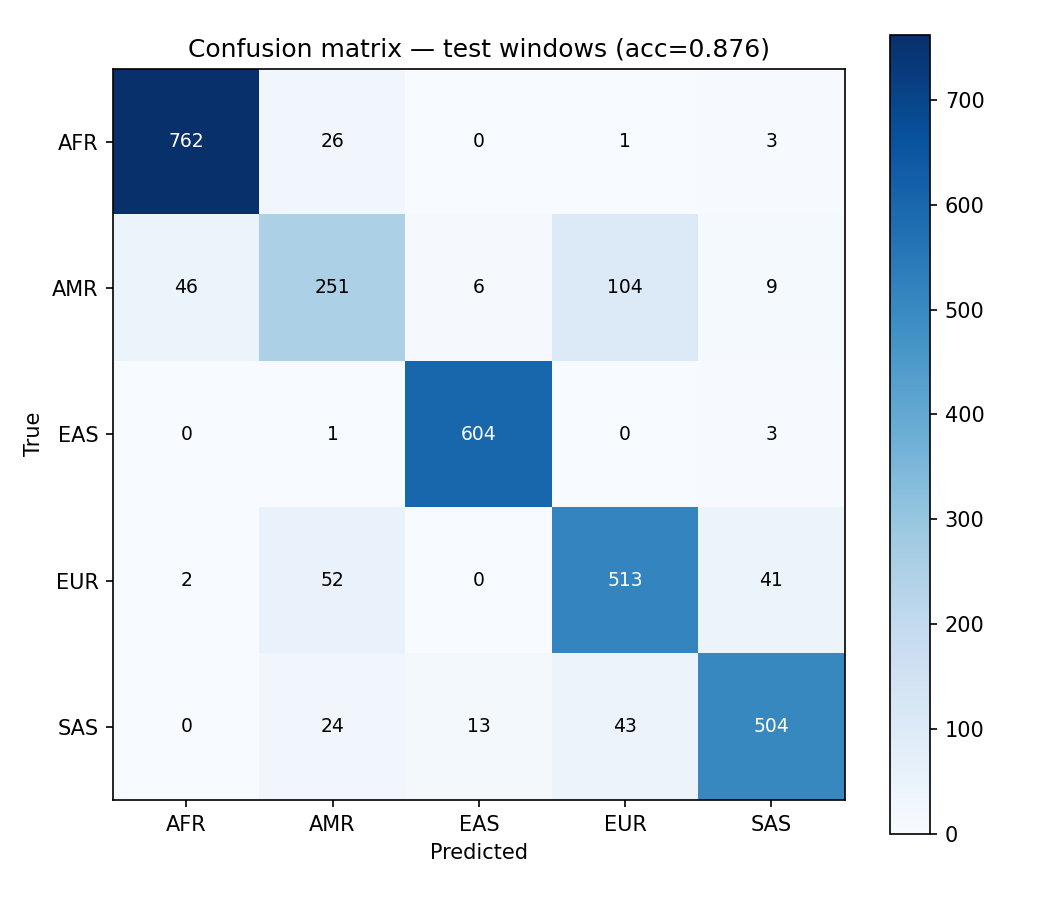

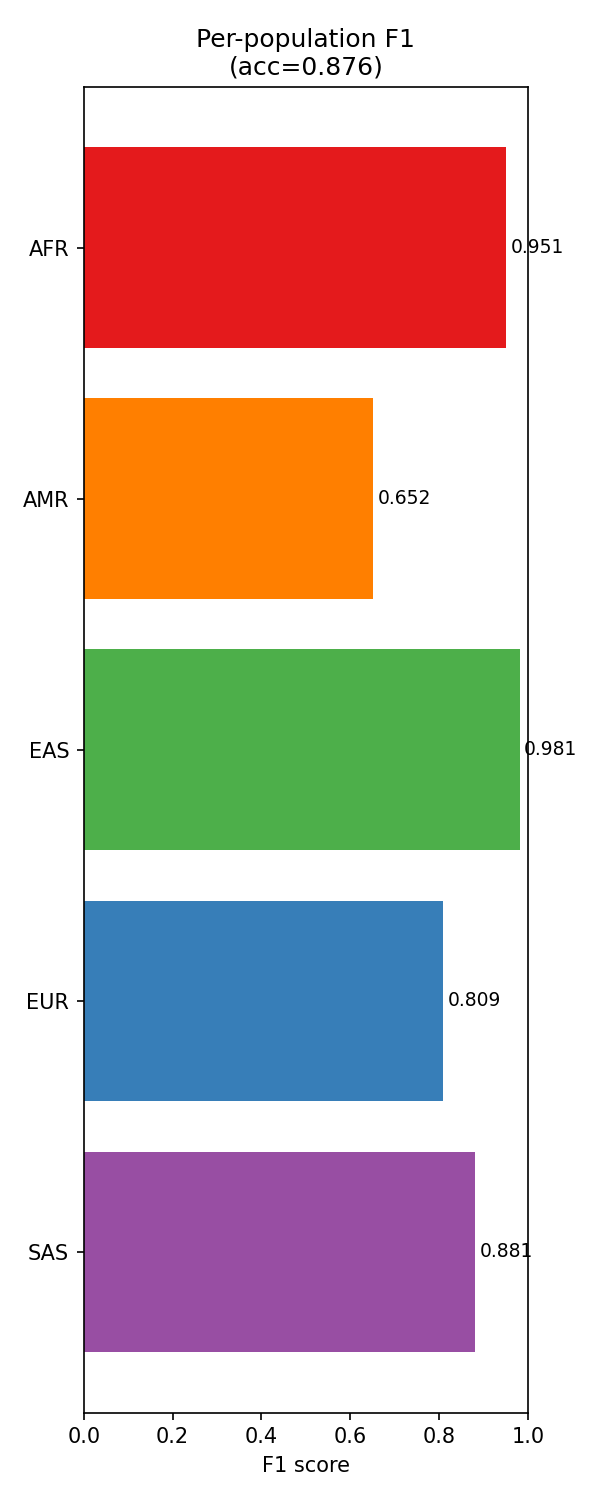

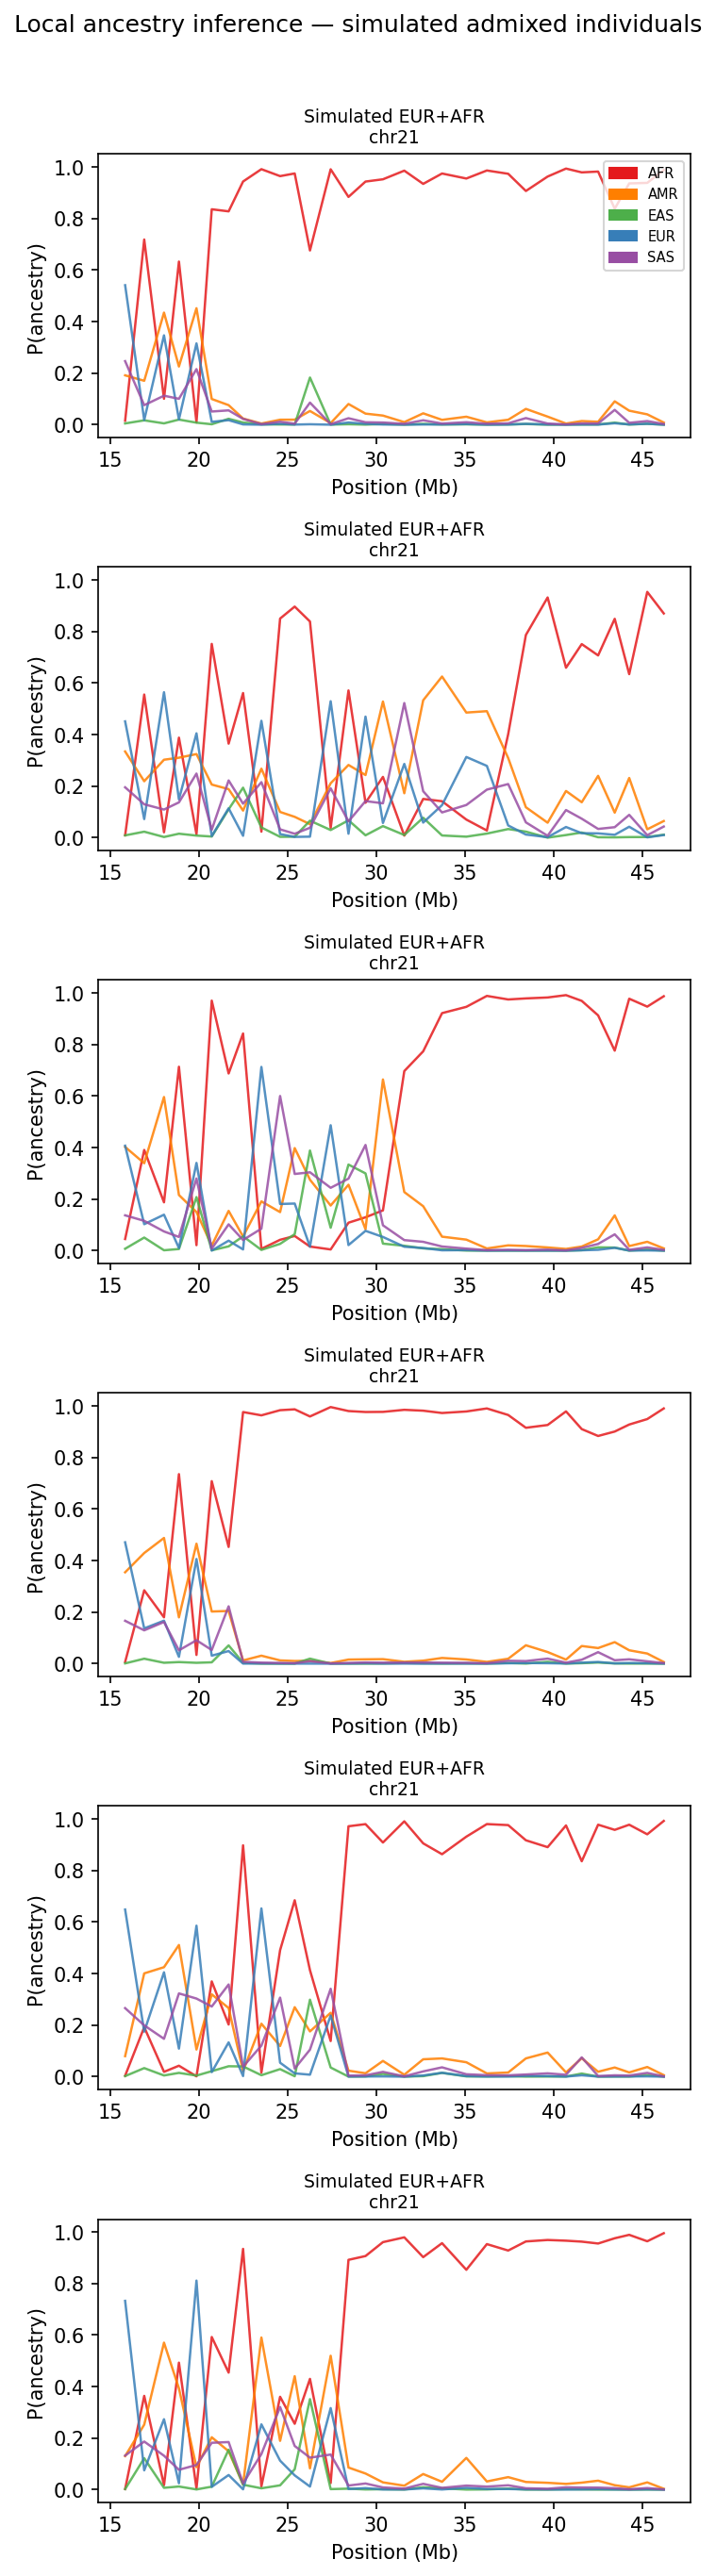

── Run B: dilated 64,128,256 [1,8,32] @ window=20k (finer LAI resolution) ──


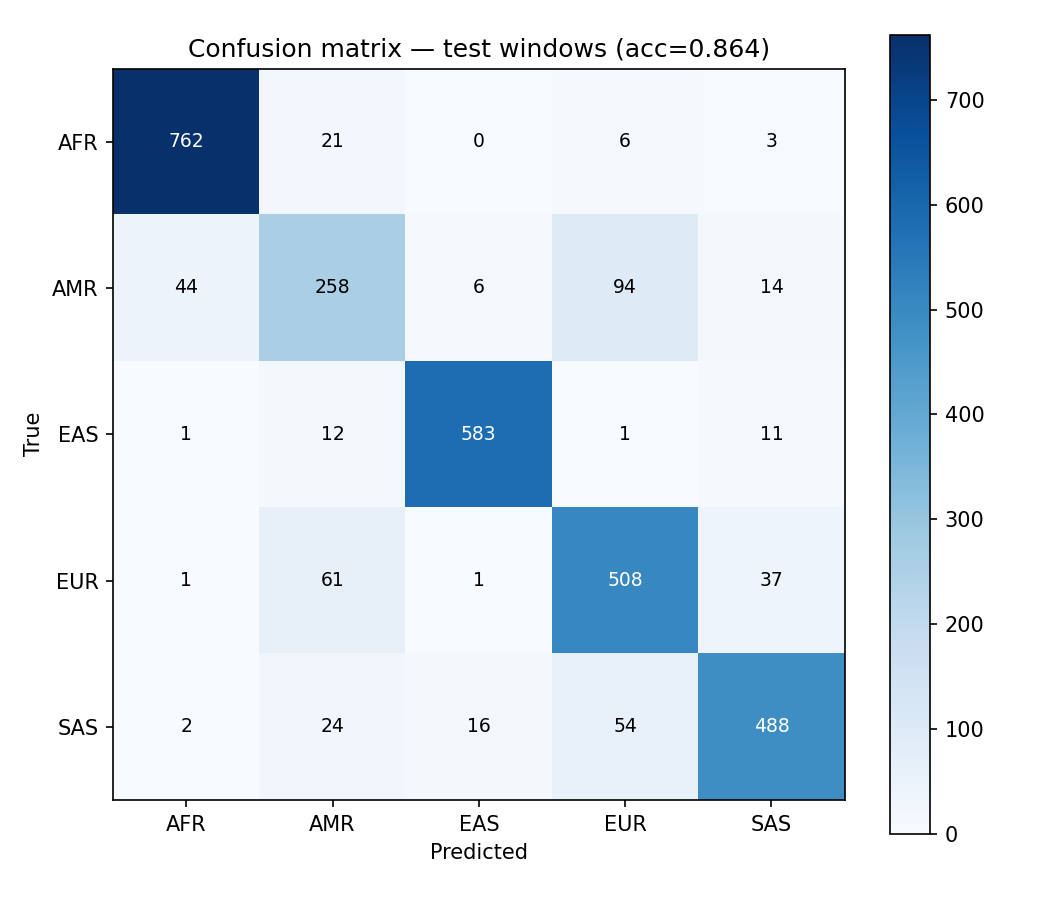

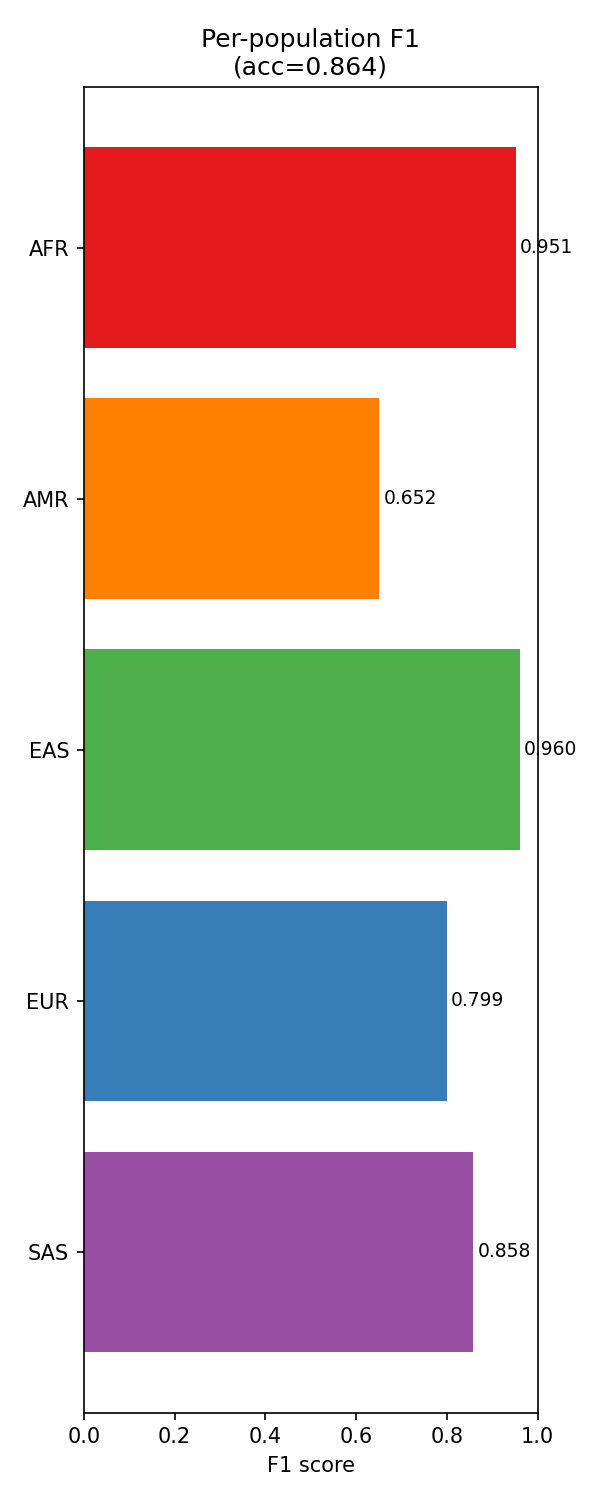

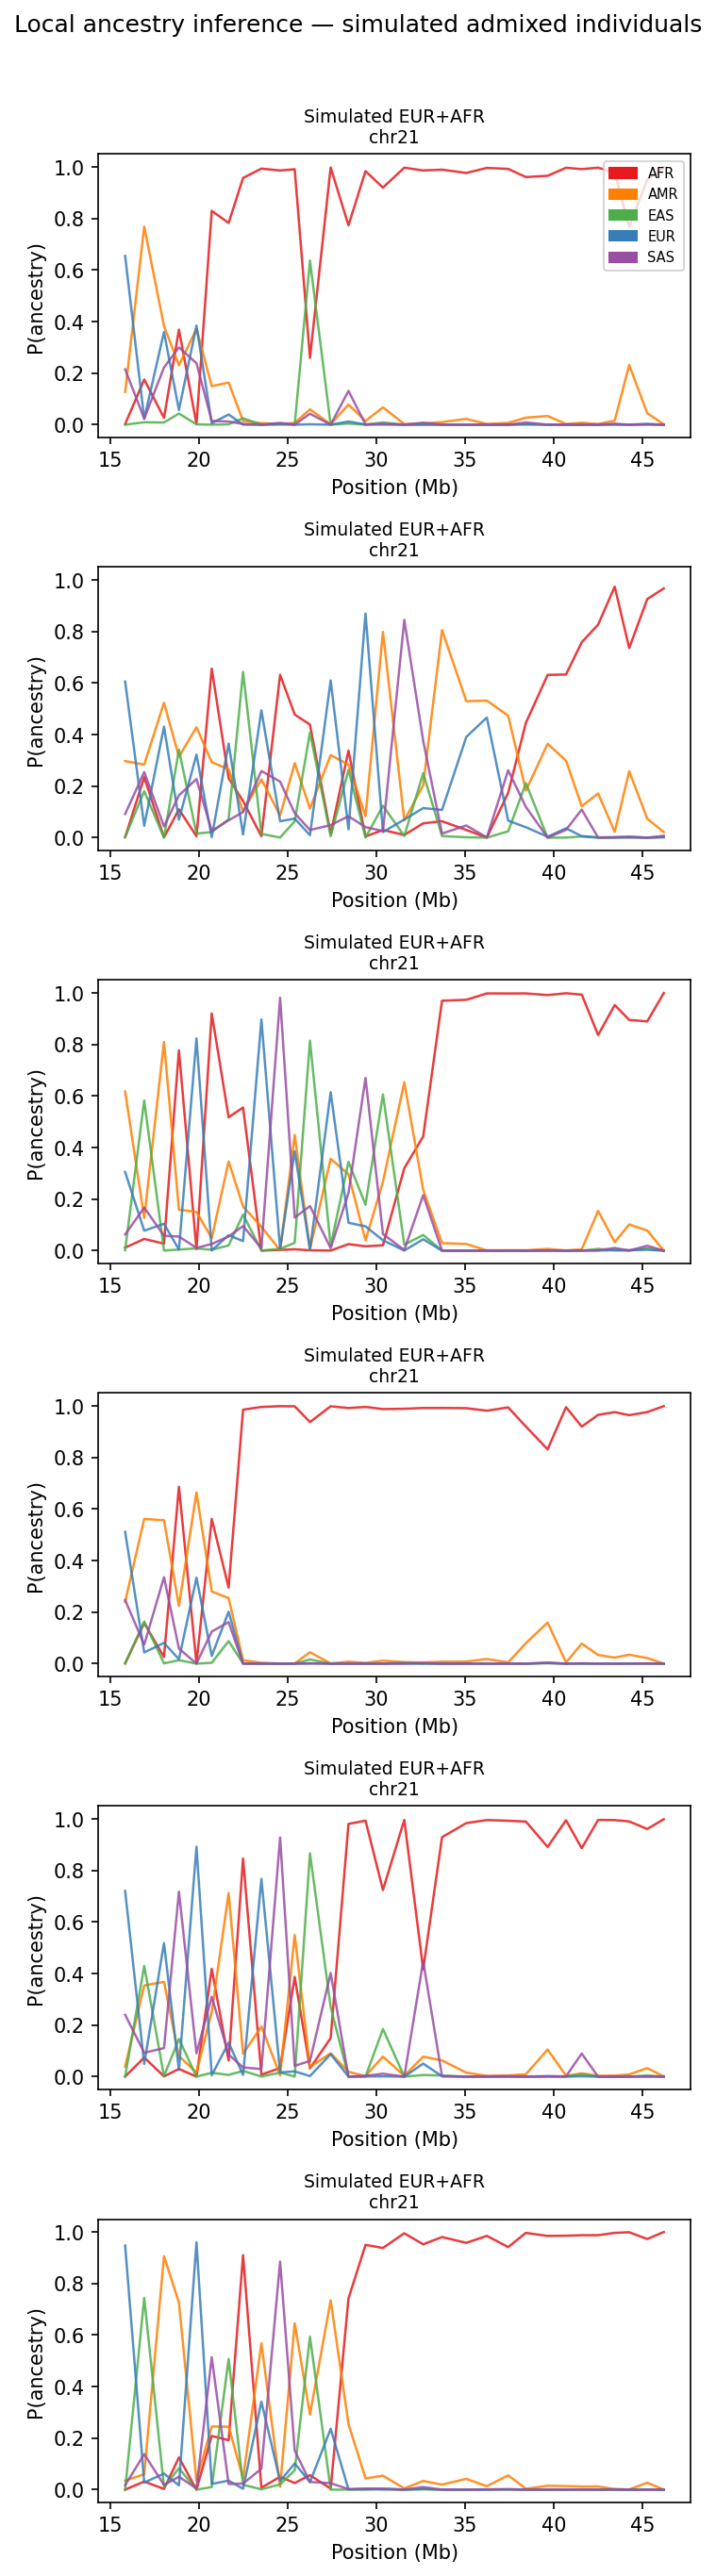

In [13]:
# ── Cell 10: display results ───────────────────────────────────────────────
from IPython.display import Image, display

print('── Run A: undilated 32,64,128 @ window=20k (highest accuracy) ──')
display(Image(CONFUSION_A))
display(Image(F1_A))
display(Image(KARYOGRAM_A))

print('── Run B: dilated 64,128,256 [1,8,32] @ window=20k (finer LAI resolution) ──')
display(Image(CONFUSION_B))
display(Image(F1_B))
display(Image(KARYOGRAM_B))